In [1]:
import pandas as pd
from sklearn import datasets


digits = datasets.load_digits()
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [2]:
df = pd.DataFrame(digits.data,columns= digits.feature_names)
print(df)

      pixel_0_0  pixel_0_1  pixel_0_2  ...  pixel_7_5  pixel_7_6  pixel_7_7
0           0.0        0.0        5.0  ...        0.0        0.0        0.0
1           0.0        0.0        0.0  ...       10.0        0.0        0.0
2           0.0        0.0        0.0  ...       16.0        9.0        0.0
3           0.0        0.0        7.0  ...        9.0        0.0        0.0
4           0.0        0.0        0.0  ...        4.0        0.0        0.0
...         ...        ...        ...  ...        ...        ...        ...
1792        0.0        0.0        4.0  ...        9.0        0.0        0.0
1793        0.0        0.0        6.0  ...        6.0        0.0        0.0
1794        0.0        0.0        1.0  ...        6.0        0.0        0.0
1795        0.0        0.0        2.0  ...       12.0        0.0        0.0
1796        0.0        0.0       10.0  ...       12.0        1.0        0.0

[1797 rows x 64 columns]


In [3]:
df["target"] = digits.target
print(df)

      pixel_0_0  pixel_0_1  pixel_0_2  ...  pixel_7_6  pixel_7_7  target
0           0.0        0.0        5.0  ...        0.0        0.0       0
1           0.0        0.0        0.0  ...        0.0        0.0       1
2           0.0        0.0        0.0  ...        9.0        0.0       2
3           0.0        0.0        7.0  ...        0.0        0.0       3
4           0.0        0.0        0.0  ...        0.0        0.0       4
...         ...        ...        ...  ...        ...        ...     ...
1792        0.0        0.0        4.0  ...        0.0        0.0       9
1793        0.0        0.0        6.0  ...        0.0        0.0       0
1794        0.0        0.0        1.0  ...        0.0        0.0       8
1795        0.0        0.0        2.0  ...        0.0        0.0       9
1796        0.0        0.0       10.0  ...        1.0        0.0       8

[1797 rows x 65 columns]


In [4]:
Y = df["target"]
X = df.drop("target", axis = "columns")
print(X)

      pixel_0_0  pixel_0_1  pixel_0_2  ...  pixel_7_5  pixel_7_6  pixel_7_7
0           0.0        0.0        5.0  ...        0.0        0.0        0.0
1           0.0        0.0        0.0  ...       10.0        0.0        0.0
2           0.0        0.0        0.0  ...       16.0        9.0        0.0
3           0.0        0.0        7.0  ...        9.0        0.0        0.0
4           0.0        0.0        0.0  ...        4.0        0.0        0.0
...         ...        ...        ...  ...        ...        ...        ...
1792        0.0        0.0        4.0  ...        9.0        0.0        0.0
1793        0.0        0.0        6.0  ...        6.0        0.0        0.0
1794        0.0        0.0        1.0  ...        6.0        0.0        0.0
1795        0.0        0.0        2.0  ...       12.0        0.0        0.0
1796        0.0        0.0       10.0  ...       12.0        1.0        0.0

[1797 rows x 64 columns]


In [35]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    train_size= 0.8,
    random_state=42
)



In [27]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors= 10)

model.fit(X_train, Y_train)
model.score(X_test, Y_test)

pred = model.predict(X_train)

In [28]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_train, pred)
print(cm)

[[145   0   0   0   0   0   0   0   0   0]
 [  0 154   0   0   0   0   0   0   0   0]
 [  0   1 142   0   0   0   0   1   0   0]
 [  0   0   0 147   0   0   0   1   1   0]
 [  0   0   0   0 133   0   0   1   1   0]
 [  0   0   0   0   0 133   0   0   0   2]
 [  0   0   0   0   0   0 146   0   0   0]
 [  0   0   0   0   0   0   0 145   0   0]
 [  0   7   1   2   0   0   0   1 133   0]
 [  0   1   0   2   0   1   0   0   2 134]]


<Axes: >

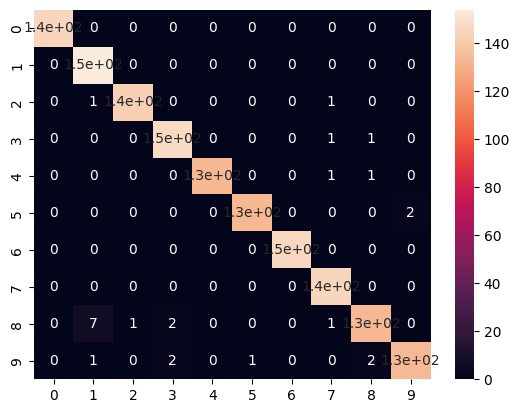

In [29]:
import seaborn as sb
sb.heatmap(cm,annot= True)

In [34]:
from sklearn.metrics import classification_report

print(classification_report(Y_train,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       145
           1       0.94      1.00      0.97       154
           2       0.99      0.99      0.99       144
           3       0.97      0.99      0.98       149
           4       1.00      0.99      0.99       135
           5       0.99      0.99      0.99       135
           6       1.00      1.00      1.00       146
           7       0.97      1.00      0.99       145
           8       0.97      0.92      0.95       144
           9       0.99      0.96      0.97       140

    accuracy                           0.98      1437
   macro avg       0.98      0.98      0.98      1437
weighted avg       0.98      0.98      0.98      1437

